In [1]:
import matplotlib.pyplot as plt
import numpy as np
from prettytable import PrettyTable

In [2]:
def least_square_fitting(X, Y,X_axis,Y_axis,plot,params):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = [ ]

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)

    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5
    if params==True:
        #Printing slopes,intercepts and errors
        table2 = PrettyTable()
        table2.title = "Slope, Intercept and Errors"
        table2.add_row(["Slope" , round(A,3) ])
        table2.add_row(["Intercept" , round(B,3) ])
        table2.add_row(["Error in y", round(error_y,3) ])
        table2.add_row(["Delta" , round(delta,5) ])
        table2.add_row(["Error in slope", round(error_slope,5) ])
        table2.add_row(["Error in intercept", round(error_intercept,5) ])
        print(table2)
        print()

    if plot==True:
        #GRAPH PLOT
        plt.xlabel(X_axis)
        plt.ylabel(Y_axis)
        plt.title(X_axis + " vs " + Y_axis)
        plt.grid()
        plt.scatter(X,Y,label='Data Points',s=20,c='orange')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit
        plt.plot(x_fit,y_fit,'--', label = f'Least-square fit line : y = ({round(A,3)}±{round(error_slope,3)})x + ({round(B,3)}±{round(error_intercept,3)})')
        plt.legend()
        plt.show()
    if plot==False and params==False:
        return ['Slope = ', A, 'Intercept = ', B, 'Error in slope = ', error_slope, 'Error in intercept = ', error_intercept]


+-------------------------------+
|  Slope, Intercept and Errors  |
+--------------------+----------+
|      Field 1       | Field 2  |
+--------------------+----------+
|       Slope        | 1084.621 |
|     Intercept      |  66.885  |
|     Error in y     |  34.161  |
|       Delta        | 321.725  |
|   Error in slope   |  6.8669  |
| Error in intercept | 13.6111  |
+--------------------+----------+



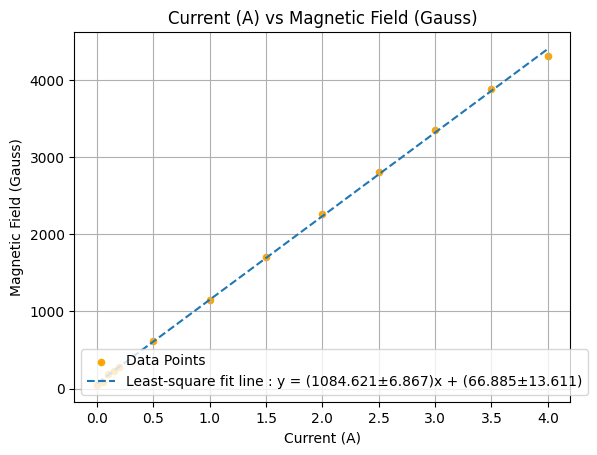

In [3]:
# magnetic field calibration
I = [0,0.05,0.1,0.15,0.2,0.5,1,1.5,2,2.5,3,3.5,4] # Current in Amperes
H = [47,88,183,228,285,614,1143,1707,2270,2810,3350,3890,4320] # Magnetic field in Gauss
least_square_fitting(I, H,"Current (A)","Magnetic Field (Gauss)",True,True)
def mag_cal_eqn(I):
    H=[]
    for i in range(len(I)):
        H.append(round(1084.621*I[i] + 66.885,3))
    return H

+--------------------------------+
|  Slope, Intercept and Errors   |
+--------------------+-----------+
|      Field 1       |  Field 2  |
+--------------------+-----------+
|       Slope        |   3.439   |
|     Intercept      |   1.018   |
|     Error in y     |   0.983   |
|       Delta        | 857.05126 |
|   Error in slope   |  0.10622  |
| Error in intercept |  0.53188  |
+--------------------+-----------+



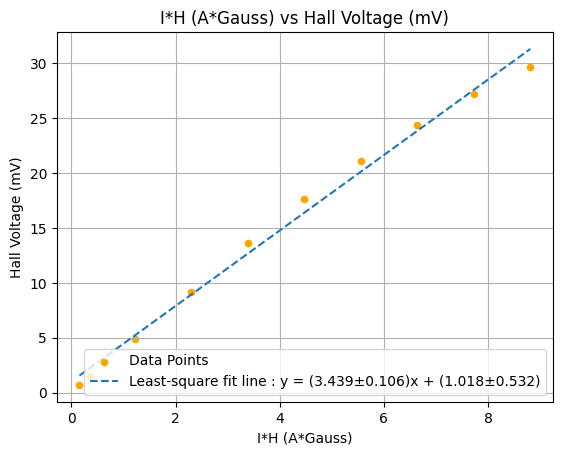

+--------------------------------+
|  Slope, Intercept and Errors   |
+--------------------+-----------+
|      Field 1       |  Field 2  |
+--------------------+-----------+
|       Slope        |   -2.407  |
|     Intercept      |   -4.717  |
|     Error in y     |   0.265   |
|       Delta        | 387.43048 |
|   Error in slope   |  0.03807  |
| Error in intercept |  0.21092  |
+--------------------+-----------+



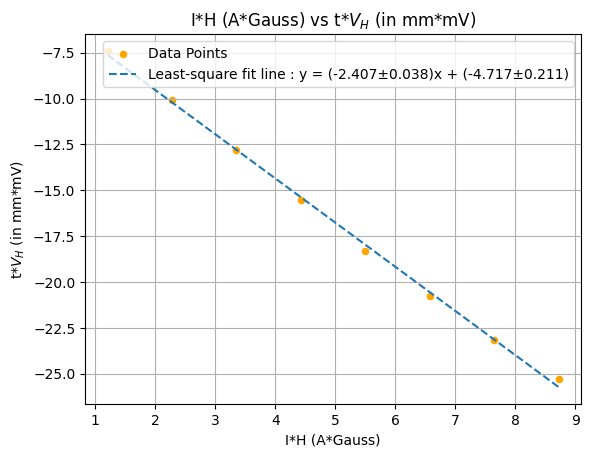

+--------------------------------+
|  Slope, Intercept and Errors   |
+--------------------+-----------+
|      Field 1       |  Field 2  |
+--------------------+-----------+
|       Slope        |   -1.529  |
|     Intercept      |   -0.044  |
|     Error in y     |   0.115   |
|       Delta        | 324.75614 |
|   Error in slope   |   0.0192  |
| Error in intercept |  0.07245  |
+--------------------+-----------+



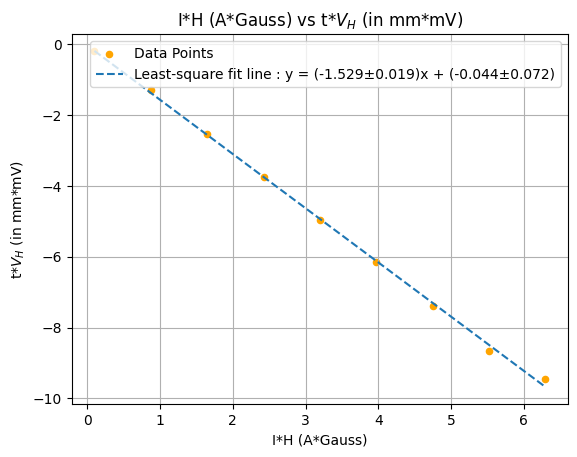

In [14]:
#  R_H calculation at room temperature

# 1.) for p-type Germanium
Ip = 2e-3 # probe current in Amperes
I= [0.01,0.1,0.5,1,1.5,2,2.5,3,3.5,4] # Current in Amperes
V_hall = [2.4,3.2,6.6,10.9,15.3,19.3,22.8,26.1,28.9,31.4] # Hall voltage in mV
V_offsets= 1.7 # Hall voltage offset in mV
Corr_V_h = [round(V_hall[i]-V_offsets,3) for i in range(len(V_hall))] # Corrected Hall voltage in mV
H_inG = mag_cal_eqn(I) # Magnetic field in Gauss
IH = [round(Ip*H_inG[i],3) for i in range(len(I))]
least_square_fitting(IH, Corr_V_h,"I*H (A*Gauss)","Hall Voltage (mV)",True,True)

# 2.) for n-type Germanium
t_ge = 0.5 # in mm
Ipp = 1.98e-3 # probe current in Amperes 
In= [0.5,1,1.5,2,2.5,3,3.5,4] # Current in Amperes
V_hall_n = [-10.4,-15.8,-21.2,-26.7,-32.2,-37.1,-41.9,-46.2] # Hall voltage in mV
V_offsets_n= 4.4 # Hall voltage offset in mV
Corr_V_h_n = [round(t_ge*(V_hall_n[i]-V_offsets_n),3) for i in range(len(V_hall_n))] # Corrected Hall voltage in mV
H_inG_n = mag_cal_eqn(In) # Magnetic field in Gauss
IH_n = [round(Ipp*H_inG_n[i],3) for i in range(len(In))]
least_square_fitting(IH_n, Corr_V_h_n,"I*H (A*Gauss)","t*$V_H$ (in mm*mV)",True,True)

# 3.) for n-type Silicon
t_si = 0.5 # in mm
Ipp_silicon = 1.43e-3 # probe current in Amperes 
In_silicon= [0,0.5,1,1.5,2,2.5,3,3.5,4] # Current in Amperes
V_hall_n_silicon = [7.1,4.9,2.4,0,-2.4,-4.8,-7.3,-9.8,-11.4] # Hall voltage in mV
V_offsets_n_silicon= 7.5 # Hall voltage offset in mV
Corr_V_h_n_silicon = [round(t_si*(V_hall_n_silicon[i]-V_offsets_n_silicon),3) for i in range(len(V_hall_n_silicon))] # Corrected Hall voltage in mV
H_inG_n_silicon = mag_cal_eqn(In_silicon) # Magnetic field in Gauss
IH_n_silicon = [round(Ipp_silicon*H_inG_n_silicon[i],3) for i in range(len(In_silicon))]
least_square_fitting(IH_n_silicon, Corr_V_h_n_silicon,"I*H (A*Gauss)","t*$V_H$ (in mm*mV)",True,True)

In [5]:
# fitting calibration equation FOR CHROMEL-ALUMEL 
Y =[] # temperture
for i in range(0,120):
    Y.append(i)
X = [0.00 ,0.04 ,0.08 ,0.12 ,0.16 ,0.20 ,0.24,0.28,0.32,0.36,0.40 ,0.44 ,0.48 ,0.52 ,0.56,0.60,0.64,0.68,0.72,0.76,0.80 ,0.84 ,0.88 ,0.92 ,0.96 
     ,1.00,1.04,1.08,1.12,1.16,1.20 ,1.24 ,1.28 ,1.32 ,1.36,1.40 ,1.44,1.49,1.53,1.57,1.61,1.65,1.69,1.73,1.77,1.81,1.85,1.90,1.94,1.98,2.02,2.06,
     2.10,2.14,2.18,2.23,2.27,2.31,2.35,2.39,2.43,2.47,2.51,2.56,2.60,2.64,2.68,2.72,2.76,2.80,2.85,2.89,2.93,2.97,3.01,3.05,3.10,3.14,3.18,3.22,
     3.26,3.30,3.35,3.39,3.43,3.47,3.51,3.56,3.60,3.64,3.68,3.72,3.76,3.81,3.85,3.89,3.93,3.97,4.01,4.06,4.10,4.14,4.18,4.22,4.26,4.31,4.35,4.39,
     4.43,4.47,4.51,4.55,4.60,4.64,4.68,4.72,4.76,4.80,4.84,4.88] # thermoelectric emf
least_square_fitting(X, Y,"Thermoelectric EMF (mV)","Temperature (°C)",False,False)

['Slope = ',
 np.float64(24.290787536258705),
 'Intercept = ',
 np.float64(0.6474702642345366),
 'Error in slope = ',
 np.float64(0.017467961545374874),
 'Error in intercept = ',
 np.float64(0.04910830363541195)]

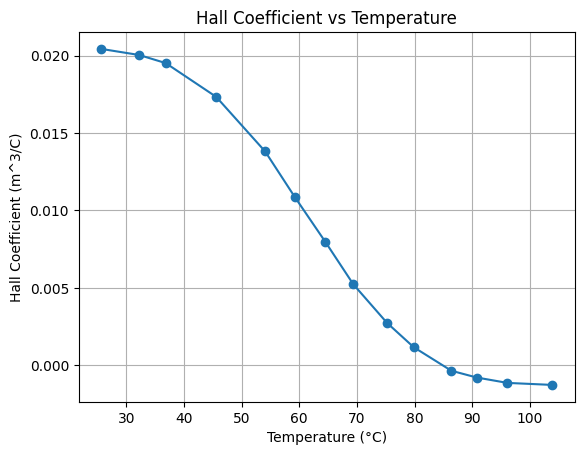

In [22]:
T_emf = [1.03,1.30,1.49,1.85,2.20,2.41,2.63,2.83,3.07,3.26,3.53,3.71,3.93,4.25] # Thermoelectric emf
V_h = [51.2,50.3,48.6,43.4,34.8,27.9,20.7,13.9,7.7,3.7,0,-1.2,-2,-2.2] # Hall voltage
H_C = [] # Heater current
V_off = [4.3,4.3,3.8,3.6,3.1,2.9,2.4,1.9,1.4,1,0.8,0.6,0.6,0.7] # Offset voltage
Temp = [] # Temperature (in C)

Corr_V_h = [] # Corrected Hall voltage
for i in range(len(V_h)):
    Corr_V_h.append(round(V_h[i] - V_off[i], 3))
# print(Corr_V_h)
# fitted calibration equation FOR CHROMEL-ALUMEL is y = (24.291+- 0.017)x + (0.647+-0.049)
for emf in T_emf:
    Temp.append(round(24.291*emf + 0.647, 2))
# print(Temp)
H = 2.97 - 0.101 # Magnetic field in K Gauss
t = 0.5 # Thickness of the sample in mm
I = 4 # Current through the sample in mA
R_h = [] # Hall coefficient
for V in Corr_V_h:
    R_h.append((V*t)/(I*H)*10**(-2))
plt.plot(Temp, R_h, marker='o')
plt.xlabel('Temperature (°C)')
plt.ylabel('Hall Coefficient (m^3/C)')
plt.title('Hall Coefficient vs Temperature')
plt.grid()
plt.show()


